<a href="https://colab.research.google.com/github/nicolasDavalos/sis420_IA_Davalos_Alvarez_Nicolas_Darko/blob/main/lab04_sis420_Davalos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

conexion a drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


librerias

In [ ]:
# utilizado para la manipulación de directorios y rutas
import os

# Cálculo científico y vectorial para python
import numpy as np

# Libreria para graficos
from matplotlib import pyplot

# Modulo de optimizacion en scipy
from scipy import optimize

# modulo para cargar archivos en formato MATLAB
# from scipy.io import loadmat

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

cagar dataset

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/IA/lab04/test.csv')

In [ ]:
print("=== SHAPE ===")
print(df.shape)

print("\n=== COLUMNAS ===")
print(df.columns.tolist())

print("\n=== TIPOS DE DATOS ===")
print(df.dtypes)

print("\n=== CLASES ===")
print(df.iloc[:, -1].value_counts())  # asume que la última columna es la etiqueta

print("\n=== NULOS ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n=== COLUMNAS CON VARIANZA CERO ===")
cols_num = df.select_dtypes(include=[float, int]).columns
print(df[cols_num].columns[df[cols_num].var() == 0].tolist())

=== SHAPE ===
(1176851, 47)

=== COLUMNAS ===
['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label']

=== TIPOS DE DATOS ===
flow_duration      float64
Header_Length      float64
Protocol Type      float64
Duration           float64
Rate               float64
Srate              float64
Drate              float64
fin_flag_number    float64
syn_flag_number    float64
rst_flag_number    float64
psh_flag_number    float64
ack_flag_number    float64
ece_flag_number    float64
cwr_flag_number    float64
ack_count          flo

In [ ]:
# Cargar dataset
df = pd.read_csv('/content/drive/MyDrive/IA/lab04/test.csv')

# Eliminar columnas con varianza cero (no aportan información)
cols_varianza_cero = ['Telnet', 'SMTP', 'IRC']
df.drop(columns=cols_varianza_cero, inplace=True)

print(f"Features tras limpieza: {df.shape[1] - 1}")  # → 43
print(f"Clases:\n{df['label'].value_counts()}")

Features tras limpieza: 43
Clases:
label
DDoS-ICMP_Flood            180447
DDoS-UDP_Flood             136717
DDoS-TCP_Flood             113735
DDoS-PSHACK_Flood          103326
DDoS-SYN_Flood             102208
DDoS-RSTFINFlood           101819
DDoS-SynonymousIP_Flood     90480
DoS-UDP_Flood               83627
DoS-TCP_Flood               67697
DoS-SYN_Flood               51116
BenignTraffic               27709
Mirai-greeth_flood          24934
Mirai-udpplain              22536
Mirai-greip_flood           19279
DDoS-ICMP_Fragmentation     11402
MITM-ArpSpoofing             7840
DDoS-ACK_Fragmentation       7292
DDoS-UDP_Fragmentation       7224
DNS_Spoofing                 4570
Recon-HostDiscovery          3331
Recon-OSScan                 2433
Recon-PortScan               2082
DoS-HTTP_Flood               1805
VulnerabilityScan             913
DDoS-HTTP_Flood               709
DDoS-SlowLoris                622
DictionaryBruteForce          319
SqlInjection                  148
Browser

aplicare valanceo de clases y tambien usarea las que no tenian un desvalanse tan grande, solo usare 6 clases que tenian mas de 100000 ejemplos, las valanceare y terminare con un dataset con 600000 ejemplos y 44 columnas

In [ ]:
# Las 6 clases más representativas del dataset
clases_elegidas = [
    'DDoS-ICMP_Flood',
    'DDoS-UDP_Flood',
    'DDoS-TCP_Flood',
    'DDoS-PSHACK_Flood',
    'DDoS-SYN_Flood',
    'DDoS-RSTFINFlood'
]

# Filtrar solo esas clases y tomar 100,000 ejemplos de cada una
df_balanceado = (df[df['label'].isin(clases_elegidas)]
                   .groupby('label')
                   .apply(lambda x: x.sample(100000, random_state=42))
                   .reset_index(drop=True))

print(f"Ejemplos por clase:\n{df_balanceado['label'].value_counts()}")
print(f"Shape final: {df_balanceado.shape}")
# Esperado: (600000, 44) — 43 features + 1 columna label

Ejemplos por clase:
label
DDoS-ICMP_Flood      100000
DDoS-PSHACK_Flood    100000
DDoS-RSTFINFlood     100000
DDoS-SYN_Flood       100000
DDoS-TCP_Flood       100000
DDoS-UDP_Flood       100000
Name: count, dtype: int64
Shape final: (600000, 44)


/tmp/ipykernel_8183/1759445789.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(100000, random_state=42))


cargare las 43 columnas de eentrada y la columna de salida

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Convertir etiquetas texto → números
le = LabelEncoder()
df_balanceado['label'] = le.fit_transform(df_balanceado['label'])

# Mostrar qué número corresponde a cada clase
print("Mapeo de clases:")
for i, clase in enumerate(le.classes_):
    print(f"  {i} → {clase}")

# Separar features y etiquetas (X e y como pide el enunciado)
X = df_balanceado.drop(columns=['label']).values  # (600000, 43)
y = df_balanceado['label'].values                 # (600000,)

num_labels = len(le.classes_)        # 6
input_layer_size = X.shape[1]        # 43

print(f"\nm = {X.shape[0]} ejemplos")
print(f"n = {input_layer_size} features")
print(f"num_labels = {num_labels} clases")

Mapeo de clases:
  0 → DDoS-ICMP_Flood
  1 → DDoS-PSHACK_Flood
  2 → DDoS-RSTFINFlood
  3 → DDoS-SYN_Flood
  4 → DDoS-TCP_Flood
  5 → DDoS-UDP_Flood

m = 600000 ejemplos
n = 43 features
num_labels = 6 clases


separacion de ejemplos, 80% de entrenamiento y 20% de preuba

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape}  → 80% = 480,000 ejemplos")
print(f"X_test:  {X_test.shape}   → 20% = 120,000 ejemplos")

X_train: (480000, 43)  → 80% = 480,000 ejemplos
X_test:  (120000, 43)   → 20% = 120,000 ejemplos


In [ ]:
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (480000, 43)
X_test:  (120000, 43)
y_train: (480000,)
y_test:  (120000,)


normalizaremos las variables entre 0 y 1

In [ ]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1  # ← única corrección: evitar división por cero
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

volvemos a hacer la divixion de 80/20 pero esta vez normalizada para que x/y_train y x/y_test esten normalizadas

In [ ]:
from sklearn.model_selection import train_test_split

# Normalizar X completo
X_norm, mu, sigma = featureNormalize(X)

# División 80/20 DESPUÉS de normalizar
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape} ")
print(f"X_test:  {X_test.shape} ")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (480000, 43) 
X_test:  (120000, 43) 
y_train: (480000,)
y_test:  (120000,)


In [ ]:
print("Primera fila X_norm:", X_norm[0, :5])
print("Primeras etiquetas y:", y[:10])

Primera fila X_norm: [-0.00690229 -0.16428351 -1.25113978 -0.15392657 -0.0896651 ]
Primeras etiquetas y: [0 0 0 0 0 0 0 0 0 0]


In [ ]:
# Verificar que existen todas las clases
print("Clases únicas en y:", np.unique(y, return_counts=True))

# Ver etiquetas de distintas posiciones
print("y[0:5]      →", y[0:5])        # clase 0
print("y[100000:100005] →", y[100000:100005])  # clase 1
print("y[200000:200005] →", y[200000:200005])  # clase 2

Clases únicas en y: (array([0, 1, 2, 3, 4, 5]), array([100000, 100000, 100000, 100000, 100000, 100000]))
y[0:5]      → [0 0 0 0 0]
y[100000:100005] → [1 1 1 1 1]
y[200000:200005] → [2 2 2 2 2]


se agrega la columna de 1 y muestra que si se agregao una columna

In [ ]:
# X_train ya está normalizado, solo registramos dimensiones
m, n = X_train.shape
print(f"m = {m} ejemplos de entrenamiento")
print(f"n = {n} features")
# X_train NO lleva columna de unos aquí, OneVsAllOM la agrega internamente

m = 480000 ejemplos de entrenamiento
n = 44 features


# vectorizacion y regrecion **logistica**

creamos la funcion sigmoide

In [ ]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

creamos la funcion de costo

In [ ]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

descenso por gradiente

In [ ]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)
        J_history.append(calcularCosto(theta, X, y))

    return theta, J_history

In [ ]:
def lrCostFunction(theta, X, y, lambda_):
    m = y.size

    if y.dtype == bool:
        y = y.astype(int)

    h = sigmoid(X.dot(theta.T))
    h = np.clip(h, 1e-10, 1 - 1e-10)  # evita log(0)

    temp = theta.copy()
    temp[0] = 0

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) + \
        (lambda_ / (2 * m)) * np.sum(np.square(temp))

    grad = (1 / m) * (h - y).dot(X)
    grad = grad + (lambda_ / m) * temp

    return J, grad

# **Vectorización regularizada de la regresión logística**

debido a tiempo, un enorme numero de iteracciones y problemas de rendimiento usaremos ON vs ALLOM, entrena un clasificador con cada clase como una pregunta para saber si es o no esta clase

In [ ]:
def OneVsAllOM(X, y, num_labels, lambda_):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n))  # n=44, sin sumar +1

    # X ya trae columna de unos, NO agregar otra vez
    costos_por_clase = []

    for c in np.arange(num_labels):
        initial_theta = np.zeros(n)

        options = {'maxiter': 100}
        res = optimize.minimize(lrCostFunction,
                                initial_theta,
                                (X, (y == c), lambda_),
                                jac=True,
                                method='CG',
                                options=options)

        all_theta[c] = res.x
        costos_por_clase.append(res.fun)
        print(f"Clase {c} entrenada - Costo final: {res.fun:.4f}")

    pyplot.figure(figsize=(8, 4))
    pyplot.bar(np.arange(num_labels), costos_por_clase, color='steelblue')
    pyplot.xlabel('Clase')
    pyplot.ylabel('Costo final J')
    pyplot.title('Costo final por clase (One-vs-All)')
    pyplot.xticks(np.arange(num_labels),
                  ['ICMP_Flood', 'PSHACK', 'RSTFINFlood',
                   'SYN_Flood', 'TCP_Flood', 'UDP_Flood'],
                  rotation=15)
    pyplot.tight_layout()
    pyplot.show()

    return all_theta, costos_por_clase

Clase 0 entrenada - Costo final: 0.0007
Clase 1 entrenada - Costo final: 0.0020
Clase 2 entrenada - Costo final: 0.0006
Clase 3 entrenada - Costo final: 0.0017
Clase 4 entrenada - Costo final: 0.0016
Clase 5 entrenada - Costo final: 0.0012


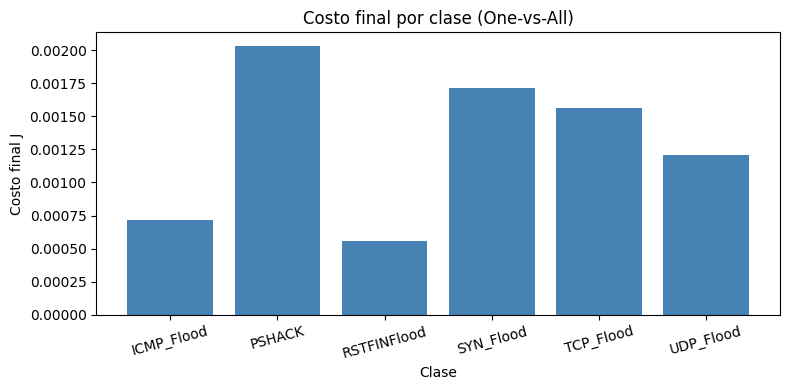


Shape all_theta: (6, 44)


In [ ]:
lambda_ = 0.1
all_theta, costos = OneVsAllOM(X_train, y_train, num_labels, lambda_)

print(f"\nShape all_theta: {all_theta.shape}")
# Esperado: (6, 44) → 6 clases, 43 features + 1 intercepción

In [ ]:
def predictOneVsAll(all_theta, X):
    m = X.shape[0]
    num_labels = all_theta.shape[0]

    # X ya trae columna de unos, NO agregar otra vez
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis=1)

    return p

In [ ]:
print("all_theta:\n", all_theta)

# Precisión sobre conjunto de entrenamiento
pred_train = predictOneVsAll(all_theta, X_train)
print('Precisión conjunto entrenamiento: {:.2f}%'.format(np.mean(pred_train == y_train) * 100))

# Precisión sobre conjunto de prueba (datos que el modelo nunca vio)
pred_test = predictOneVsAll(all_theta, X_test)
print('Precisión conjunto prueba:        {:.2f}%'.format(np.mean(pred_test == y_test) * 100))

# Muestra de 45 ejemplos del conjunto de prueba
print("\n--- Muestra de predicciones vs etiquetas reales (45 ejemplos de prueba) ---")
muestra = X_test[100:145, :]
pred_muestra = predictOneVsAll(all_theta, muestra)
print("Predicciones:", pred_muestra)
print("Etiquetas:   ", y_test[100:145])

all_theta:
 [[-6.33458278e+00  8.54040698e-03  5.26825866e-02 -2.11612777e+00
  -7.42241011e-02  2.44007778e-02  2.44007778e-02  0.00000000e+00
  -7.19906614e-02 -4.33593783e-01 -1.07610893e-01 -3.68407391e-01
   4.33627565e-01  0.00000000e+00  0.00000000e+00 -8.00555643e-02
   2.14072450e-01 -4.80715244e-02  3.88085093e-02 -5.54212926e-02
  -1.47153395e-01  1.94494179e-01 -1.31584881e-02  0.00000000e+00
  -2.49781437e+00 -3.52694961e-01  9.87831448e-04 -1.25415118e-03
   4.07138931e+00  1.25415118e-03  1.25415118e-03 -8.86505908e-02
   3.42218421e-02 -1.14274905e-01  2.06429257e-01  1.67084671e-01
   7.41761206e-03  8.61565428e-03  2.92927466e-03 -3.07169108e-01
   1.42407987e-01 -1.21983646e-01  4.96096057e-01 -2.08573679e-03]
 [-6.68903722e+00  3.67642439e-04  5.81860055e-02 -2.54083384e-01
   1.01230271e-01 -4.09940893e-02 -4.09940893e-02  0.00000000e+00
  -2.88055028e+00 -3.35387269e-01  2.68565145e+00  4.60028018e+00
   1.48316473e+00  0.00000000e+00  0.00000000e+00 -2.77732253e+

grafica de precicion

              precision    recall  f1-score   support

  ICMP_Flood       1.00      1.00      1.00     20000
      PSHACK       1.00      1.00      1.00     20000
 RSTFINFlood       1.00      1.00      1.00     20000
   SYN_Flood       1.00      1.00      1.00     20000
   TCP_Flood       1.00      1.00      1.00     20000
   UDP_Flood       1.00      1.00      1.00     20000

    accuracy                           1.00    120000
   macro avg       1.00      1.00      1.00    120000
weighted avg       1.00      1.00      1.00    120000



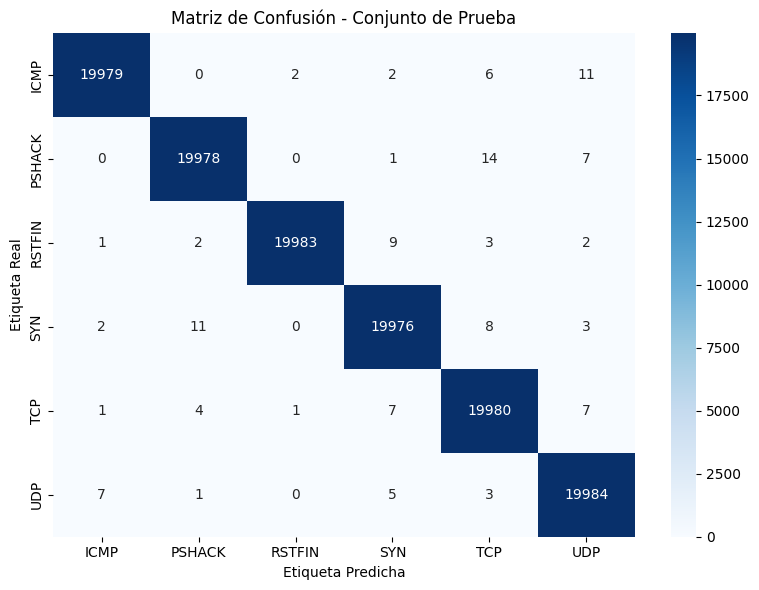

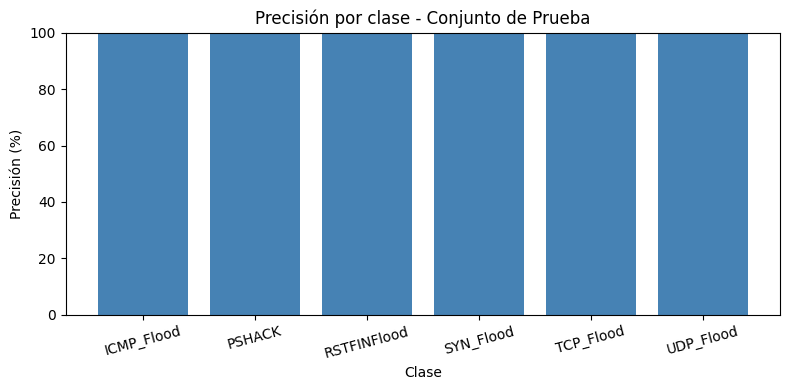

In [ ]:
# Gráfica de precisión por clase
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Reporte por clase
print(classification_report(y_test, pred_test,
      target_names=['ICMP_Flood','PSHACK','RSTFINFlood',
                    'SYN_Flood','TCP_Flood','UDP_Flood']))

# Matriz de confusión
cm = confusion_matrix(y_test, pred_test)
pyplot.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ICMP','PSHACK','RSTFIN','SYN','TCP','UDP'],
            yticklabels=['ICMP','PSHACK','RSTFIN','SYN','TCP','UDP'])
pyplot.title('Matriz de Confusión - Conjunto de Prueba')
pyplot.ylabel('Etiqueta Real')
pyplot.xlabel('Etiqueta Predicha')
pyplot.tight_layout()
pyplot.show()

# Precisión por clase en barra
precisiones = cm.diagonal() / cm.sum(axis=1) * 100
pyplot.figure(figsize=(8, 4))
pyplot.bar(np.arange(num_labels), precisiones, color='steelblue')
pyplot.xlabel('Clase')
pyplot.ylabel('Precisión (%)')
pyplot.title('Precisión por clase - Conjunto de Prueba')
pyplot.xticks(np.arange(num_labels),
              ['ICMP_Flood','PSHACK','RSTFINFlood',
               'SYN_Flood','TCP_Flood','UDP_Flood'],
              rotation=15)
pyplot.ylim([0, 100])
pyplot.tight_layout()
pyplot.show()

demostracion:

In [ ]:
clases_nombres = ['ICMP_Flood','PSHACK_Flood','RSTFINFlood',
                  'SYN_Flood','TCP_Flood','UDP_Flood']

print(f"{'Ejemplo':>8} | {'Real':>20} | {'Predicho':>20} | {'Correcto':>10}")
print("-" * 68)
for i in range(10):
    real     = clases_nombres[y_test[i]]
    predicho = clases_nombres[pred_test[i]]
    correcto = "Si" if y_test[i] == pred_test[i] else "No"
    print(f"{i:>8} | {real:>20} | {predicho:>20} | {correcto:>10}")

 Ejemplo |                 Real |             Predicho |   Correcto
--------------------------------------------------------------------
       0 |            TCP_Flood |            TCP_Flood |         Si
       1 |           ICMP_Flood |           ICMP_Flood |         Si
       2 |           ICMP_Flood |           ICMP_Flood |         Si
       3 |            TCP_Flood |            TCP_Flood |         Si
       4 |            UDP_Flood |            UDP_Flood |         Si
       5 |            TCP_Flood |            TCP_Flood |         Si
       6 |            UDP_Flood |            UDP_Flood |         Si
       7 |            SYN_Flood |            SYN_Flood |         Si
       8 |           ICMP_Flood |           ICMP_Flood |         Si
       9 |         PSHACK_Flood |         PSHACK_Flood |         Si


# **empezamos con el dataset 2**

cargar datos


In [ ]:
import pandas as pd

# Cargar imágenes y etiquetas de KMNIST
PATH = '/content/drive/MyDrive/IA/lab04/chino/'

X_raw = np.load(PATH + 'kmnist-train-imgs.npz')['arr_0']   # (60000, 28, 28)
y_raw = np.load(PATH + 'kmnist-train-labels.npz')['arr_0'] # (60000,)

# Aplanar imágenes 28x28 → 784 features (cada pixel = 1 columna)
X = X_raw.reshape(60000, -1).astype(float)  # (60000, 784)
y = y_raw.astype(int)                        # (60000,)

# Convertir a DataFrame de pandas (requisito del enunciado)
df = pd.DataFrame(X)
df['label'] = y

# Variables de configuración
input_layer_size = X.shape[1]  # 784
num_labels = len(np.unique(y)) # 10
m = X.shape[0]                 # 60000

print(f"input_layer_size: {input_layer_size}")  # 784
print(f"num_labels: {num_labels}")              # 10
print(f"m: {m}")                                # 60000
print(f"Shape X: {X.shape}")
print(f"Clases: {np.unique(y, return_counts=True)}")

input_layer_size: 784
num_labels: 10
m: 60000
Shape X: (60000, 784)
Clases: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))


mostrara los datos

In [ ]:
def displayData(X, example_width=28, figsize=(10, 10)):
    """
    Muestra imagenes de KMNIST almacenadas en X en una cuadricula.
    """
    if X.ndim == 2:
        m, n = X.shape
    elif X.ndim == 1:
        n = X.size
        m = 1
        X = X[None]
    else:
        raise IndexError('La entrada X debe ser 1 o 2 dimensional.')

    example_height = example_width

    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    fig, ax_array = pyplot.subplots(display_rows, display_cols, figsize=figsize)
    fig.subplots_adjust(wspace=0.025, hspace=0.025)

    ax_array = [ax_array] if m == 1 else ax_array.ravel()

    for i, ax in enumerate(ax_array):
        # KMNIST no necesita order='F' como el formato MATLAB
        ax.imshow(X[i].reshape(example_width, example_height), cmap='gray')
        ax.axis('off')

mostrara 10 imagenes aleatorias

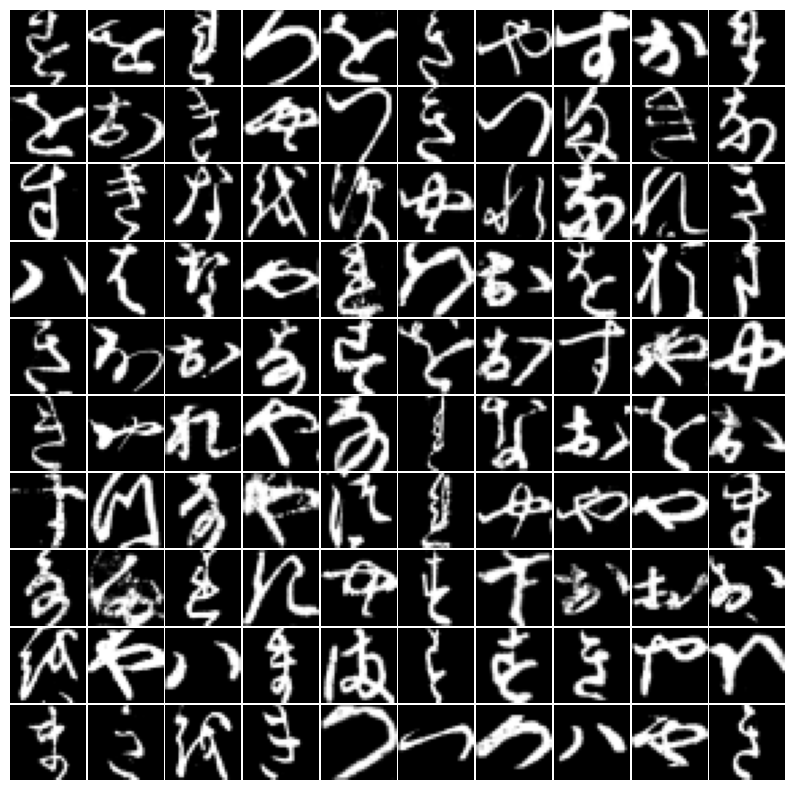

In [ ]:
rand_indices = np.random.choice(m, 100, replace=False)
sel = X[rand_indices, :]
displayData(sel)

In [ ]:
# valores de prueba para los parámetros theta
theta_t = np.array([-2, -1, 1, 2], dtype=float)

# valores de prueba para las entradas
X_t = np.concatenate([np.ones((5, 1)), np.arange(1, 16).reshape(5, 3, order='F')/10.0], axis=1)

# valores de testeo para las etiquetas
y_t = np.array([1, 0, 1, 0, 1])

# valores de testeo para el parametro de regularizacion
lambda_t = 3

se crea ka funcion sigmoide

In [ ]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

In [ ]:
def lrCostFunction(theta, X, y, lambda_):
    m = y.size

    if y.dtype == bool:
        y = y.astype(int)

    h = sigmoid(X.dot(theta.T))
    h = np.clip(h, 1e-10, 1 - 1e-10)

    temp = theta.copy()
    temp[0] = 0

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) + \
        (lambda_ / (2 * m)) * np.sum(np.square(temp))

    grad = (1 / m) * (h - y).dot(X) + (lambda_ / m) * temp

    return J, grad

compara costo y gradiente calculados

In [ ]:
J, grad = lrCostFunction(theta_t, X_t, y_t, lambda_t)

print('Costo         : {:.6f}'.format(J))
print('Costo esperado: 2.534819')
print('-----------------------')
print('Gradientes:')
print(' [{:.6f}, {:.6f}, {:.6f}, {:.6f}]'.format(*grad))


Costo         : 2.534819
Costo esperado: 2.534819
-----------------------
Gradientes:
 [0.146561, -0.548558, 0.724722, 1.398003]


divicion de 80% entrenamiento y 20% prueba y normalizacion de pixeles

In [ ]:
from sklearn.model_selection import train_test_split

# Normalizar píxeles de 0-255 a 0-1
X_norm = X / 255.0

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # mantiene balance de clases en ambos conjuntos
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Clases en train: {np.unique(y_train, return_counts=True)}")

X_train: (48000, 784)
X_test:  (12000, 784)
Clases en train: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([4800, 4800, 4800, 4800, 4800, 4800, 4800, 4800, 4800, 4800]))


In [ ]:
def oneVsAll(X, y, num_labels, lambda_):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))

    # X_train no trae columna de unos, se agrega aquí correctamente
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    costos_por_clase = []

    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)
        options = {'maxiter': 100}
        res = optimize.minimize(lrCostFunction,
                                initial_theta,
                                (X, (y == c), lambda_),
                                jac=True,
                                method='CG',
                                options=options)
        all_theta[c] = res.x
        costos_por_clase.append(res.fun)
        print(f"Clase {c} entrenada - Costo final: {res.fun:.4f}")

    # Grafica de costo final por clase
    pyplot.figure(figsize=(8, 4))
    pyplot.bar(np.arange(num_labels), costos_por_clase, color='steelblue')
    pyplot.xlabel('Clase')
    pyplot.ylabel('Costo final J')
    pyplot.title('Costo final por clase (One-vs-All) - KMNIST')
    pyplot.xticks(np.arange(num_labels),
              [f'Clase {i}' for i in range(num_labels)],
              rotation=15, fontsize=9)
    pyplot.tight_layout()
    pyplot.show()

    return all_theta, costos_por_clase

entrenar

Clase 0 entrenada - Costo final: 0.0570
Clase 1 entrenada - Costo final: 0.1199
Clase 2 entrenada - Costo final: 0.1633
Clase 3 entrenada - Costo final: 0.0877
Clase 4 entrenada - Costo final: 0.1178
Clase 5 entrenada - Costo final: 0.0917
Clase 6 entrenada - Costo final: 0.1291
Clase 7 entrenada - Costo final: 0.0989
Clase 8 entrenada - Costo final: 0.0997
Clase 9 entrenada - Costo final: 0.1051


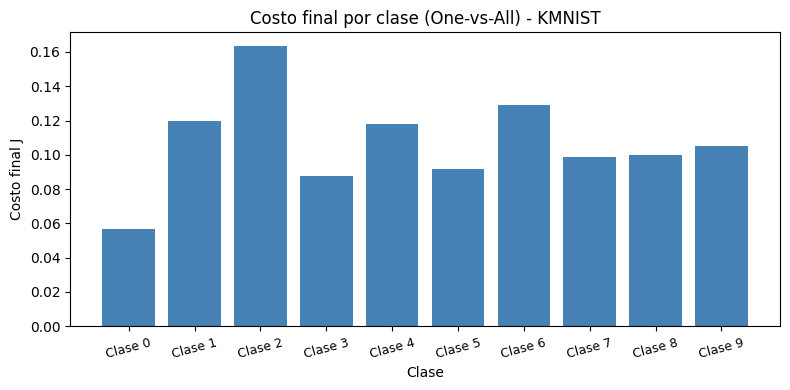

In [ ]:
lambda_ = 0.001
all_theta, costos = oneVsAll(X_train, y_train, num_labels, lambda_)

verificacion

In [ ]:
print(f"Shape all_theta: {all_theta.shape}")
# Esperado: (10, 785) → 10 clases, 784 features + 1 intercepción
print(f"Primeros 5 valores theta clase 0: {all_theta[0, :5]}")

Shape all_theta: (10, 785)
Primeros 5 valores theta clase 0: [-5.98478264  0.12119781  0.24888477 -0.0959297  -0.1246104 ]


predictOneVsAll

In [ ]:
def predictOneVsAll(all_theta, X):
    m = X.shape[0]
    num_labels = all_theta.shape[0]
    p = np.zeros(m)
    # X no trae columna de unos, se agrega aquí correctamente
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis=1)
    return p

presicion


Precision conjunto entrenamiento: 83.71%
Precision conjunto prueba:        81.12%

Predicciones: [3 0 5 9 1 0 7 9 5 0 3 1 2 7 0 9 4 8 2 1 2 9 6 4 8 8 8 0 6 9 2 0 3 0 3 6 6
 2 4 7 5 5 0 1 1 1 4 1 4 0 7 5 9 7 2 2 4 8 5 8 3 4 4 8 5 7 5 1 0 0 1 0 6 2
 4 7 0 1 1 5 5 1 8 0 4 2 0 7 2 7 8 1 1 8 3 9 0 5 6 0]
Etiquetas:    [3 4 5 9 4 0 9 1 7 4 1 1 2 7 0 9 4 8 6 1 8 9 4 4 8 8 1 4 6 9 8 7 3 0 3 6 6
 2 4 7 5 5 0 1 9 1 4 4 4 0 7 5 9 7 2 2 4 8 5 8 3 4 4 8 5 7 5 1 0 0 1 0 6 2
 4 7 0 0 1 5 5 1 2 0 4 4 9 7 2 7 8 1 1 8 3 9 0 5 6 0]


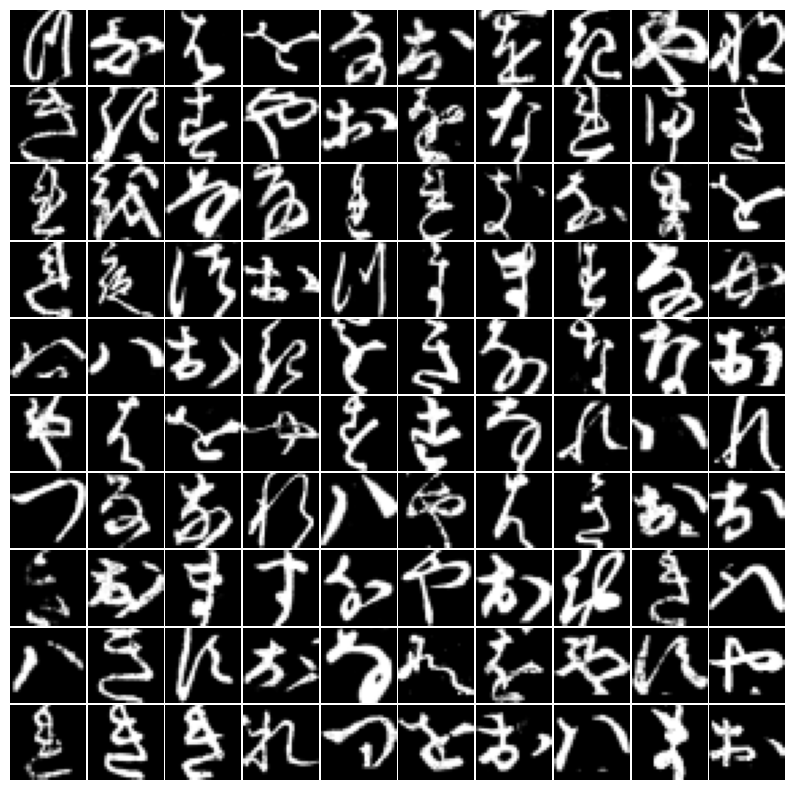

In [ ]:
# Precisión sobre conjunto de entrenamiento (80%)
pred_train = predictOneVsAll(all_theta, X_train)
print('Precision conjunto entrenamiento: {:.2f}%'.format(np.mean(pred_train == y_train) * 100))

# Precisión sobre conjunto de prueba (20% que el modelo nunca vio)
pred_test = predictOneVsAll(all_theta, X_test)
print('Precision conjunto prueba:        {:.2f}%'.format(np.mean(pred_test == y_test) * 100))

# Muestra aleatoria de 100 imágenes del conjunto de prueba
rand_indices = np.random.choice(X_test.shape[0], 100, replace=False)
XPrueba = X_test[rand_indices, :]
p = predictOneVsAll(all_theta, XPrueba)
print("\nPredicciones:", p)
print("Etiquetas:   ", y_test[rand_indices])

# Mostrar las 100 imágenes
displayData(XPrueba)

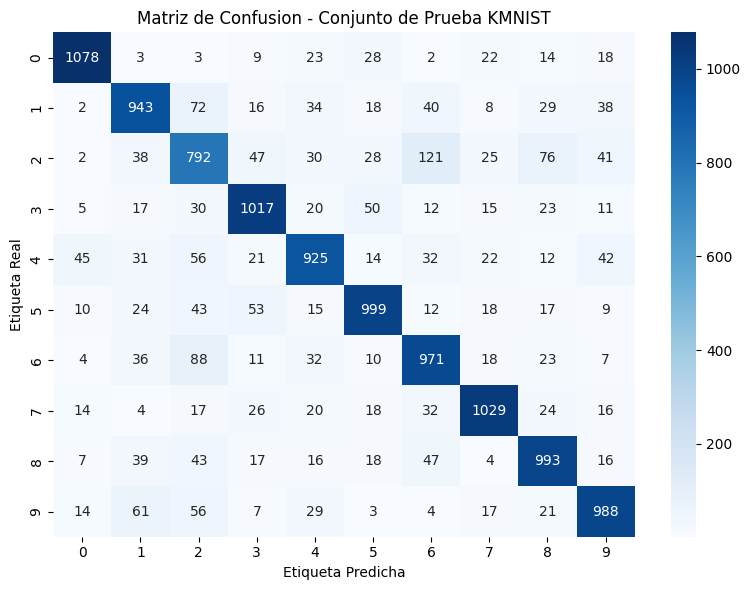

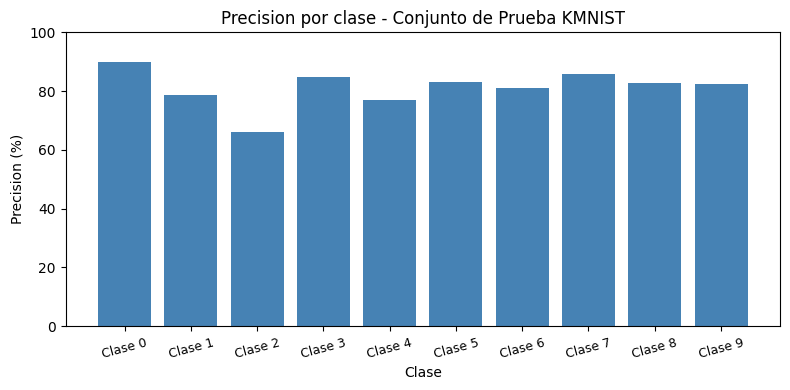


 Ejemplo |     Real | Predicho |   Correcto
---------------------------------------------
       0 |        5 |        5 |         Si
       1 |        4 |        4 |         Si
       2 |        5 |        5 |         Si
       3 |        2 |        3 |         No
       4 |        1 |        1 |         Si
       5 |        5 |        5 |         Si
       6 |        0 |        0 |         Si
       7 |        1 |        1 |         Si
       8 |        2 |        2 |         Si
       9 |        0 |        0 |         Si


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Matriz de confusion
cm = confusion_matrix(y_test, pred_test)
pyplot.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
pyplot.title('Matriz de Confusion - Conjunto de Prueba KMNIST')
pyplot.ylabel('Etiqueta Real')
pyplot.xlabel('Etiqueta Predicha')
pyplot.tight_layout()
pyplot.show()

# Precisión por clase en barra
precisiones = cm.diagonal() / cm.sum(axis=1) * 100
pyplot.figure(figsize=(8, 4))
pyplot.bar(np.arange(num_labels), precisiones, color='steelblue')
pyplot.xlabel('Clase')
pyplot.ylabel('Precision (%)')
pyplot.title('Precision por clase - Conjunto de Prueba KMNIST')
pyplot.xticks(np.arange(num_labels),
              [f'Clase {i}' for i in range(num_labels)],
              rotation=15, fontsize=9)
pyplot.ylim([0, 100])
pyplot.tight_layout()
pyplot.show()

# Tabla de predicciones vs real
print(f"\n{'Ejemplo':>8} | {'Real':>8} | {'Predicho':>8} | {'Correcto':>10}")
print("-" * 45)
for i in range(10):
    real     = y_test[i]
    predicho = pred_test[i]
    correcto = "Si" if real == predicho else "No"
    print(f"{i:>8} | {real:>8} | {predicho:>8} | {correcto:>10}")